In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/healthcare_fraud_detection.csv')

### Exploration and cleaning

In [2]:
df.dtypes

Provider_ID                                  str
Claim_ID                                     str
Patient_Age                                int64
Patient_Gender                               str
Diagnosis_Code                               str
Procedure_Code                             int64
Claim_Amount                             float64
Approved_Amount                          float64
Insurance_Type                               str
Claim_Submission_Date                        str
Days_Between_Service_and_Claim             int64
Number_of_Claims_Per_Provider_Monthly      int64
Provider_Specialty                           str
Patient_State                                str
Claim_Status                                 str
Is_Fraud                                   int64
Length_of_Stay                             int64
Visit_Type                                   str
Chronic_Condition_Flag                     int64
Prior_Visits_12m                         float64
dtype: object

In [3]:
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'])

In [4]:
con = duckdb.connect()
con.execute("CREATE OR REPLACE TABLE claims as SELECT * FROM df")

### 1. Where is fraud concentrated?

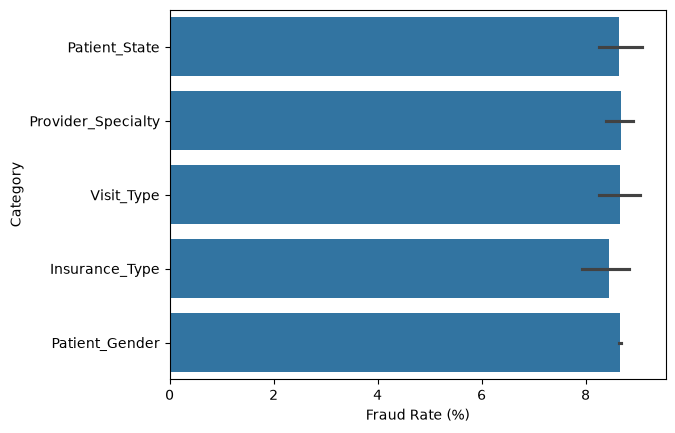

In [5]:
con.execute("""
    UPDATE claims
    SET Provider_Specialty = 'Unknown'
    WHERE Provider_Specialty IS NULL
""").df()

con.execute("""
    UPDATE claims
    SET Insurance_Type = 'Unknown'
    WHERE Insurance_Type IS NULL
""").df()

df_fraud_by_category = con.execute("""
    WITH Fraud_by_Specialty AS (
        SELECT
            'Provider_Specialty' as Category, 
            Provider_Specialty, 
            COUNT(Claim_ID) as Total_Claims,
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
            ROUND((Frauds / Total_Claims * 100.0), 2) as Fraud_Rate
            FROM claims 
            GROUP BY Provider_Specialty 
    ), 
    Fraud_by_Insurance_Type AS (
        SELECT 
            'Insurance_Type' as Category,
            Insurance_Type, 
            COUNT(Claim_ID) as Total_Claims,
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
            ROUND((Frauds / Total_Claims * 100.0), 2) as Fraud_Rate
            FROM claims 
            GROUP BY Insurance_Type 
    ), 
    Fraud_by_Patient_State AS (
        SELECT 
            'Patient_State' as Category,
            Patient_State, 
            COUNT(Claim_ID) as Total_Claims,
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
            ROUND((Frauds / Total_Claims * 100.0), 2) as Fraud_Rate
            FROM claims 
            GROUP BY Patient_State 
    ), 
    Fraud_by_Visit_Type AS (
        SELECT 
            'Visit_Type' as Category,
            Visit_Type, 
            COUNT(Claim_ID) as Total_Claims,
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
            ROUND((Frauds / Total_Claims * 100.0), 2) as Fraud_Rate
            FROM claims 
            GROUP BY Visit_Type 
    ),
    Fraud_by_Gender AS (
        SELECT
            'Patient_Gender' as Category,
            Patient_Gender, 
            COUNT(Claim_ID) as Total_Claims,
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
            ROUND((Frauds / Total_Claims * 100.0), 2) as Fraud_Rate
            FROM claims
            GROUP BY Patient_Gender
    )

    SELECT Category, Provider_Specialty as Value, Total_Claims, Frauds, Fraud_Rate
    FROM Fraud_by_Specialty

    UNION ALL

    SELECT Category, Insurance_Type as Value, Total_Claims, Frauds, Fraud_Rate
    FROM Fraud_by_Insurance_Type

    UNION ALL

    SELECT Category, Patient_State as Value, Total_Claims, Frauds, Fraud_Rate
    FROM Fraud_by_Patient_State

    UNION ALL

    SELECT Category, Visit_Type as Value, Total_Claims, Frauds, Fraud_Rate
    FROM Fraud_by_Visit_Type

    UNION ALL 

    SELECT Category, Patient_Gender as Value, Total_Claims, Frauds, Fraud_Rate
    FROM Fraud_by_Gender

    ORDER BY Fraud_Rate DESC

""").df()

ax = sns.barplot(data=df_fraud_by_category, x="Fraud_Rate", y="Category")

# Change both axis names at once
ax.set(xlabel="Fraud Rate (%)")

plt.show()

Finding: There is no clear concentration of fraud in any of the categories analyzed. Fraud rates are relatively similar across categories, ranging from approximately 8% to 9%.

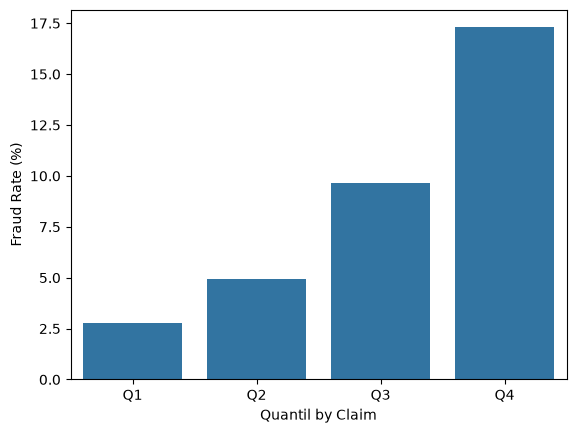

In [6]:
df_quantiles_claim_amount= con.execute("""
    WITH Quantiles AS (
        SELECT
            quantile_cont(Claim_Amount, [0.25, 0.5, 0.75]) as Quantiles            
        FROM claims
    ),
    Quantil_by_Claim AS(
        SELECT
            Claim_Id,
            Claim_Amount,
            Is_Fraud,
            (CASE
                WHEN Claim_Amount <= Quantiles[1] THEN 'Q1'
                WHEN Claim_Amount <= Quantiles[2] THEN 'Q2'
                WHEN Claim_Amount <= Quantiles[3] THEN 'Q3'
                ELSE 'Q4'
            END) as Quantil_by_Claim
        FROM claims
        CROSS JOIN Quantiles
    )

    SELECT 
        Quantil_by_Claim, 
        COUNT(Claim_ID) AS Total_Claims, 
        SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) AS Frauds, 
        ROUND(
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) 
            / COUNT(Claim_ID) * 100.0, 
            2
        ) AS Fraud_Rate
    FROM Quantil_by_Claim
    GROUP BY Quantil_by_Claim
    ORDER BY Quantil_by_Claim
""").df()

ax = sns.barplot(data=df_quantiles_claim_amount, x='Quantil_by_Claim', y='Fraud_Rate')

ax.set(xlabel='Quantil by Claim', ylabel='Fraud Rate (%)')
plt.show()

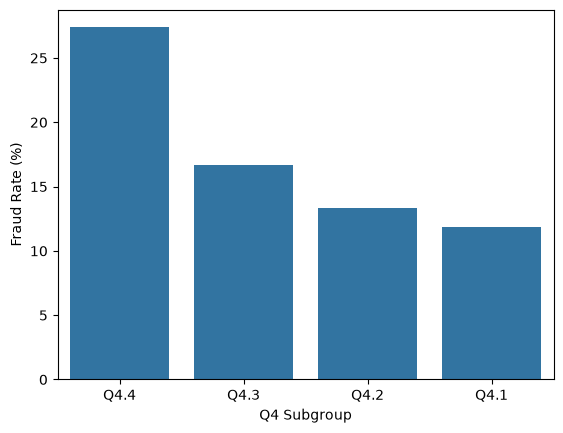

In [7]:
df_q4_claim_amount = con.execute("""
    WITH Quantiles AS (
        SELECT
            quantile_cont(Claim_Amount, [0.25, 0.5, 0.75]) AS Quantiles            
        FROM claims
    ),
    Quantil_by_Claim AS (
        SELECT
            Claim_Id,
            Claim_Amount,
            Is_Fraud,
            CASE
                WHEN Claim_Amount <= Quantiles[1] THEN 'Q1'
                WHEN Claim_Amount <= Quantiles[2] THEN 'Q2'
                WHEN Claim_Amount <= Quantiles[3] THEN 'Q3'
                ELSE 'Q4'
            END AS Quantil_by_Claim
        FROM claims
        CROSS JOIN Quantiles
    ),
    Quantil_Q4 AS (
        SELECT *
        FROM Quantil_by_Claim
        WHERE Quantil_by_Claim = 'Q4'
    ),
    Quantiles_Q4 AS (
        SELECT
            quantile_cont(Claim_Amount, [0.25, 0.5, 0.75]) AS Quantiles
        FROM Quantil_Q4
    ),
    Q4_Subgroups AS (
        SELECT
            Claim_Id,
            Claim_Amount,
            Is_Fraud,
            CASE
                WHEN Claim_Amount <= Quantiles[1] THEN 'Q4.1'
                WHEN Claim_Amount <= Quantiles[2] THEN 'Q4.2'
                WHEN Claim_Amount <= Quantiles[3] THEN 'Q4.3'
                ELSE 'Q4.4'
            END AS Q4_Subgroup
        FROM Quantil_Q4
        CROSS JOIN Quantiles_Q4
    )

    SELECT 
        Q4_Subgroup,
        COUNT(Claim_Id) AS Total_Claims,
        SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) AS Frauds,
        MIN(Claim_Amount) as Min_Amount,
        MAX(Claim_Amount) as Max_Amount,
        ROUND(
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END)
            / COUNT(Claim_Id) * 100.0,
            2
        ) AS Fraud_Rate
    FROM Q4_Subgroups
    GROUP BY Q4_Subgroup
    ORDER BY Fraud_Rate DESC;
""").df()

ax = sns.barplot(data=df_q4_claim_amount, x='Q4_Subgroup', y='Fraud_Rate')

ax.set(ylabel='Fraud Rate (%)', xlabel='Q4 Subgroup')
plt.show()

Finding: There is a clear relationship between fraud and claim amount. The main finding is that the higher the claim amount, the higher the fraud rate, as shown in the first graph. To determine whether this pattern remained within the Q4 group, I divided Q4 into four subgroups. As shown in the second graph, claims with the highest amounts also have the highest fraud rates.

In [8]:
con.execute("""
    CREATE TEMP TABLE q4_temp_table AS
    WITH Quantiles AS (
        SELECT
            quantile_cont(Claim_Amount, [0.25, 0.5, 0.75]) AS Quantiles            
        FROM claims
    ),
    Quantil_by_Claim AS (
        SELECT
            Claim_Id,
            Claim_Amount,
            Provider_Specialty,
            Insurance_Type,
            Visit_Type,
            Patient_Gender,
            Number_of_Claims_Per_Provider_Monthly,
            Is_Fraud,
            CASE
                WHEN Claim_Amount <= Quantiles[1] THEN 'Q1'
                WHEN Claim_Amount <= Quantiles[2] THEN 'Q2'
                WHEN Claim_Amount <= Quantiles[3] THEN 'Q3'
                ELSE 'Q4'
            END AS Quantil_by_Claim
        FROM claims
        CROSS JOIN Quantiles
    ),
    Quantil_Q4 AS (
        SELECT *
        FROM Quantil_by_Claim
        WHERE Quantil_by_Claim = 'Q4'
    ),
    Quantiles_Q4 AS (
        SELECT
            quantile_cont(Claim_Amount, [0.25, 0.5, 0.75]) AS Quantiles
        FROM Quantil_Q4
    ),
    Q4_Subgroups AS (
        SELECT
            Claim_Id,
            Claim_Amount,
            Provider_Specialty,
            Insurance_Type,
            Visit_Type,
            Patient_Gender,
            Number_of_Claims_Per_Provider_Monthly,
            Is_Fraud,
            CASE
                WHEN Claim_Amount <= Quantiles[1] THEN 'Q4.1'
                WHEN Claim_Amount <= Quantiles[2] THEN 'Q4.2'
                WHEN Claim_Amount <= Quantiles[3] THEN 'Q4.3'
                ELSE 'Q4.4'
            END AS Q4_Subgroup
        FROM Quantil_Q4
        CROSS JOIN Quantiles_Q4
    )
    SELECT *
    FROM Q4_Subgroups

""").df()

,Count
0,4691


In [9]:
con.execute("""
    SELECT 
        Q4_Subgroup,
        Provider_Specialty,
        COUNT(Claim_Id) as Total_Claims,
        SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
        ROUND(
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END)
            / COUNT(Claim_Id) * 100.0,
            2
        ) as Fraud_Rate
    FROM q4_temp_table
    GROUP BY Q4_Subgroup, Provider_Specialty
    ORDER BY Fraud_Rate DESC
""").df()

,Q4_Subgroup,Provider_Specialty,Total_Claims,Frauds,Fraud_Rate
0,Q4.4,Orthopedics,167,53.0,31.74
1,Q4.4,General Practice,223,69.0,30.94
2,Q4.4,Internal Medicine,251,65.0,25.90
3,Q4.4,Pulmonology,160,41.0,25.62
4,Q4.4,Neurology,166,42.0,25.30
5,Q4.3,Unknown,40,10.0,25.00
6,Q4.4,Unknown,48,12.0,25.00
7,Q4.4,Cardiology,158,39.0,24.68
8,Q4.2,Orthopedics,168,32.0,19.05
9,Q4.3,Cardiology,147,27.0,18.37


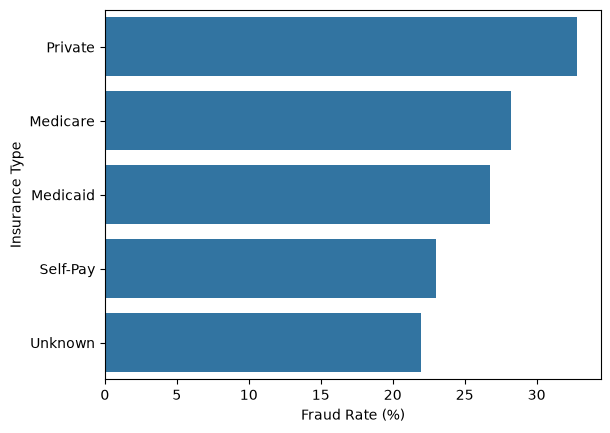

In [10]:
df_ins = con.execute("""
    SELECT 
        Q4_Subgroup,
        Insurance_Type,
        COUNT(Claim_Id) as Total_Claims,
        SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
        ROUND(
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END)
            / COUNT(Claim_Id) * 100.0,
            2
        ) as Fraud_Rate
    FROM q4_temp_table
    GROUP BY Q4_Subgroup, Insurance_Type
    ORDER BY Fraud_Rate DESC
""").df()

df_ins_q44 = df_ins[df_ins["Q4_Subgroup"] == "Q4.4"]
ax = sns.barplot(data=df_ins_q44, x='Fraud_Rate', y='Insurance_Type')

ax.set(xlabel='Fraud Rate (%)', ylabel='Insurance Type')
plt.show()

In [11]:
con.execute("""
    SELECT 
        Q4_Subgroup,
        Visit_Type,
        COUNT(Claim_Id) as Total_Claims,
        SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
        ROUND(
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END)
            / COUNT(Claim_Id) * 100.0,
            2
        ) as Fraud_Rate
    FROM q4_temp_table
    GROUP BY Q4_Subgroup, Visit_Type
    ORDER BY Fraud_Rate DESC
""").df()

,Q4_Subgroup,Visit_Type,Total_Claims,Frauds,Fraud_Rate
0,Q4.4,Emergency,400,119.0,29.75
1,Q4.4,Outpatient,400,107.0,26.75
2,Q4.4,Inpatient,373,95.0,25.47
3,Q4.3,Emergency,393,70.0,17.81
4,Q4.3,Inpatient,371,64.0,17.25
5,Q4.3,Outpatient,408,61.0,14.95
6,Q4.2,Emergency,374,55.0,14.71
7,Q4.2,Inpatient,384,53.0,13.80
8,Q4.1,Inpatient,342,43.0,12.57
9,Q4.1,Outpatient,436,53.0,12.16


In [12]:
con.execute("""
    SELECT 
        Q4_Subgroup,
        Patient_Gender,
        COUNT(Claim_Id) as Total_Claims,
        SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) as Frauds,
        ROUND(
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END)
            / COUNT(Claim_Id) * 100.0,
            2
        ) as Fraud_Rate
    FROM q4_temp_table
    GROUP BY Q4_Subgroup, Patient_Gender
    ORDER BY Fraud_Rate DESC
""").df()

,Q4_Subgroup,Patient_Gender,Total_Claims,Frauds,Fraud_Rate
0,Q4.4,Male,598,166.0,27.76
1,Q4.4,Female,575,155.0,26.96
2,Q4.3,Female,569,101.0,17.75
3,Q4.3,Male,603,94.0,15.59
4,Q4.2,Female,549,77.0,14.03
5,Q4.2,Male,624,79.0,12.66
6,Q4.1,Female,531,64.0,12.05
7,Q4.1,Male,642,75.0,11.68


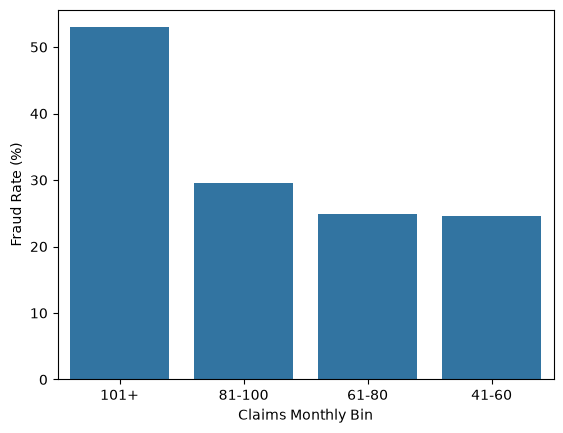

In [13]:
df_q4 = con.execute("""
    SELECT
        Q4_Subgroup,
        CASE
            WHEN Number_of_Claims_Per_Provider_Monthly <= 20 THEN '0-20'
            WHEN Number_of_Claims_Per_Provider_Monthly <= 40 THEN '21-40'
            WHEN Number_of_Claims_Per_Provider_Monthly <= 60 THEN '41-60'
            WHEN Number_of_Claims_Per_Provider_Monthly <= 80 THEN '61-80'
            WHEN Number_of_Claims_Per_Provider_Monthly <= 100 THEN '81-100'
            ELSE '101+'
        END AS Claims_Monthly_Bin,
        COUNT(Claim_Id) AS Total_Claims,
        SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END) AS Frauds,
        ROUND(
            SUM(CASE WHEN Is_Fraud THEN 1 ELSE 0 END)
            / COUNT(Claim_Id) * 100.0,
            2
        ) AS Fraud_Rate
    FROM q4_temp_table
    GROUP BY Q4_Subgroup, Claims_Monthly_Bin
    ORDER BY Fraud_Rate DESC
""").df()

df_q44 = df_q4[df_q4["Q4_Subgroup"] == "Q4.4"]

ax = sns.barplot(data=df_q44, x="Claims_Monthly_Bin", y="Fraud_Rate")

ax.set(ylabel='Fraud Rate (%)', xlabel='Claims Monthly Bin')
plt.show()

Lastly, I analyzed the categories within Q4 to identify any other relationships beyond claim amount. On the one hand, private insurance shows a clear difference compared with self-pay. On the other hand, there seems to be a clear relationship between the number of monthly claims per provider and the fraud rate. As shown in the graph above, providers with more than 101 claims per month have a fraud rate above 50%.


**Finding:** No single category shows a meaningfully higher fraud rate on its own — rates stay within an 8-9% range. However, claim amount is strongly associated with fraud, rising consistently from Q1 to Q4 and further within Q4's own subgroups. Within the highest-risk segment (Q4.4), private insurance claims show a notably higher fraud rate (32.8%) than self-pay (23.0%), and providers submitting 101+ claims per month show a fraud rate above 50%.

**Conclusion:** Claim amount is the strongest fraud indicator, and this risk compounds when combined with high provider claim volume and private insurance type.

---
### 2. How does Claim_Amount differ from Approved_Amount? Are there patterns in reductions/rejections?

In [14]:
con.execute("""
    SELECT
        ROUND(SUM(Approved_Amount) / SUM(Claim_Amount) * 100.0, 2) AS Approved_Perc
    FROM claims
""").df()

,Approved_Perc
0,83.79


Initial finding: The average approved amount is 83.79% which means, for every $100.00 the company is approving $83.79.  

In [15]:
con.execute("""
    CREATE TEMP TABLE temp_differ_table AS
    WITH Differ_Amount AS (
        SELECT 
            Claim_Amount,
            Approved_Amount,
            Claim_Status, 
            Provider_Specialty,
            Is_Fraud,
            Insurance_Type,
            Visit_Type,
            ROUND((Approved_Amount / Claim_Amount * 100.0), 2) AS Differ
        FROM claims
        ORDER BY Differ
    )
    SELECT *
    FROM Differ_Amount
""").df()

,Count
0,18764


In [16]:
con.execute("""
    SELECT 
        Is_Fraud,
        Claim_Status,
        COUNT(Claim_Status) as Total
    FROM temp_differ_table
    WHERE Differ > 100
    GROUP BY Is_Fraud, Claim_Status
    ORDER BY Total
""").df()

,Is_Fraud,Claim_Status,Total
0,1,Rejected,2
1,0,Pending,121
2,0,Rejected,217
3,0,Approved,625


Finding: An anomaly was found in the data when comparing the amounts. 965 rows show Approved_Amount > Claim_Amount, most of them (963/965) unrelated to fraud. This appears to be a data quality issue rather than a business pattern. 

This rows were not excluded from the data for the analysis due to it is just about a 10%. Furthermore, just two of those claims were  fraudulent out of 965 which does not change the differ or the analysis result. 

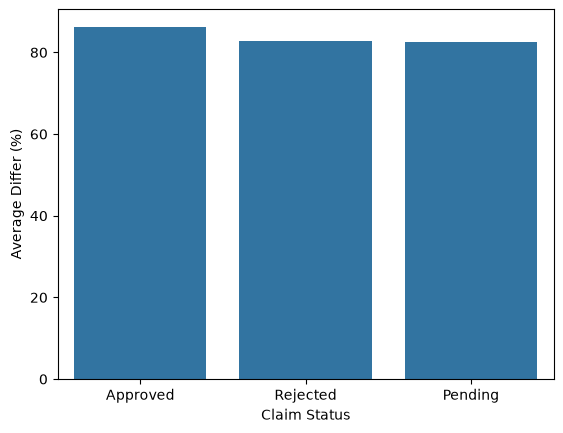

In [17]:
df_status = con.execute("""
    SELECT
        Claim_Status,
        ROUND(AVG(Differ), 2) as Avg_Differ,
        ROUND(STDDEV(Differ), 2) as Stddev_Differ,
    FROM temp_differ_table
    GROUP BY Claim_Status
    ORDER BY Stddev_Differ
""").df()

ax = sns.barplot(data=df_status, x='Claim_Status', y='Avg_Differ')

ax.set(xlabel='Claim Status', ylabel='Average Differ (%)')
plt.show()

In [18]:
con.execute("""
    SELECT
        Provider_Specialty,
        ROUND(AVG(Differ), 2) as Avg_Differ,
        ROUND(STDDEV(Differ), 2) as Stddev_Differ,
    FROM temp_differ_table
    GROUP BY Provider_Specialty
    ORDER BY Stddev_Differ
""").df()

,Provider_Specialty,Avg_Differ,Stddev_Differ
0,Unknown,84.85,11.68
1,Cardiology,85.15,11.71
2,Neurology,85.23,11.73
3,Pulmonology,85.13,11.85
4,Internal Medicine,85.19,12.10
5,General Practice,84.77,12.31
6,Orthopedics,85.24,12.44


In [19]:
con.execute("""
    SELECT
        Is_Fraud,
        ROUND(AVG(Differ), 2) as Avg_Differ,
        ROUND(STDDEV(Differ), 2) as Stddev_Differ,
    FROM temp_differ_table
    GROUP BY Is_Fraud
    ORDER BY Stddev_Differ
""").df()

,Is_Fraud,Avg_Differ,Stddev_Differ
0,0,87.37,9.07
1,1,61.20,13.43


In [20]:
con.execute("""
    SELECT
        Insurance_Type,
        ROUND(AVG(Differ), 2) as Avg_Differ,
        ROUND(STDDEV(Differ), 2) as Stddev_Differ,
    FROM temp_differ_table
    GROUP BY Insurance_Type
    ORDER BY Stddev_Differ
""").df()

,Insurance_Type,Avg_Differ,Stddev_Differ
0,Private,84.78,11.96
1,Self-Pay,85.18,11.99
2,Medicare,85.28,12.04
3,Medicaid,85.17,12.10
4,Unknown,85.01,12.48


In [21]:
con.execute("""
    SELECT
        Visit_Type,
        ROUND(AVG(Differ), 2) as Avg_Differ,
        ROUND(STDDEV(Differ), 2) as Stddev_Differ,
    FROM temp_differ_table
    GROUP BY Visit_Type
    ORDER BY Stddev_Differ
""").df()

,Visit_Type,Avg_Differ,Stddev_Differ
0,Inpatient,85.23,11.86
1,Outpatient,85.00,12.02
2,Emergency,85.08,12.23


I analyzed by group to determine whether the difference between the claim amount and approved amount is related with other factors such as specialty, visit type, fraud, and so on. 

The main finding was that the approval criteria does not discriminate by specialty, visit type and insurance type; which means that the approval process is standarized in that sense. However, it does highly distinguish when there is fraud -as we will see below-. 

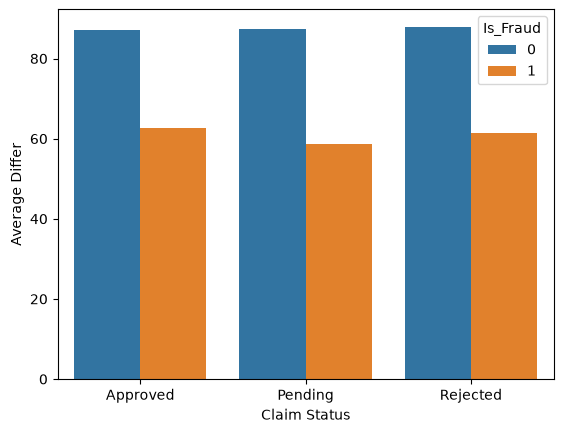

In [22]:
df_fraud_by_status = con.execute("""
    SELECT
        Is_Fraud,
        Claim_Status,
        ROUND(AVG(Differ), 2) as Avg_Differ,
        ROUND(STDDEV(Differ), 2) as Stddev_Differ
    FROM temp_differ_table
    GROUP BY Is_Fraud, Claim_Status
    ORDER BY Is_Fraud
""").df()

ax = sns.barplot(data=df_fraud_by_status, x='Claim_Status', y='Avg_Differ', hue='Is_Fraud')

ax.set(xlabel='Claim Status', ylabel='Average Differ')

plt.show()

**Conclusion:** On average, the company recognizes 83.79% of the claimed amount. This recognition rate does not vary meaningfully by specialty, visit type, or insurance type (all averaging ~85%, stddev ~12), indicating a standardized approval process across those dimensions. However, fraud status has a strong and independent effect: fraudulent claims are recognized at a much lower rate (61.20% vs. 87.37% for non-fraudulent) and with more variability, and this gap persists even within Approved claims specifically (62.62% vs. 87.24%) — ruling out claim status as the underlying driver. Separately, 965 rows showed Approved_Amount exceeding Claim_Amount, almost entirely unrelated to fraud; this was flagged as a likely data quality issue rather than a business pattern, and does not materially affect the findings above.

---
### 3. Does Days_Between_Service_and_Claim differ between fraudulent and non-fraudulent claims?

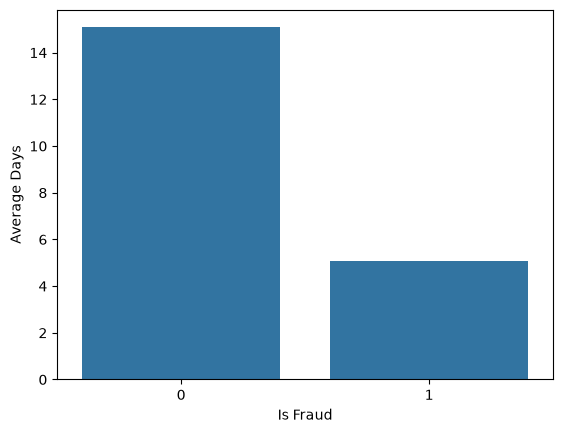

In [29]:
df_avg_days = con.execute("""
    SELECT
        Is_Fraud,
        AVG(Days_Between_Service_and_Claim) as Avg_Days
    FROM claims
    GROUP BY Is_Fraud
""").df()

ax = sns.barplot(data=df_avg_days, x='Is_Fraud', y='Avg_Days')

ax.set(xlabel='Is Fraud', ylabel='Average Days')
plt.show()

In [ ]:
con.execute("""
    SELECT
        Is_Fraud,
        AVG(Days_Between_Service_and_Claim) as Avg_Days,
        STDDEV(Days_Between_Service_and_Claim) as Stddev_Days,
    FROM claims
    GROUP BY Is_Fraud
""").df()

,Is_Fraud,Avg_Days,Stddev_Days
0,0,15.077192,8.098367
1,1,5.063385,5.399580


Yes, the initial finding showed a significant difference in the average days when the claim is submitted after the service. Being 15.07 days for those non-fraudulent claims and 5.06 days for the fraudulent claims. The standard deviation for those fraudulent claims is also more consistent than those non-fraudulent claims, indicating a possible constant pattern in the fraudulent claims. 

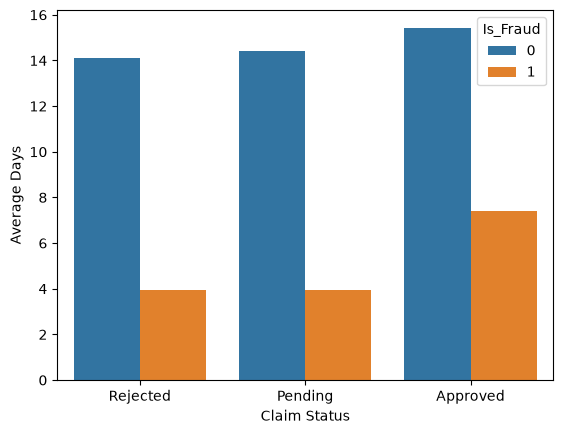

In [70]:
df_avg_days_status = con.execute("""
    SELECT
        Is_Fraud,
        Claim_Status,
        AVG(Days_Between_Service_and_Claim) as Avg_Days,
    FROM claims
    GROUP BY Is_Fraud, Claim_Status
    ORDER BY Avg_Days
""").df()

ax = sns.barplot(data=df_avg_days_status, x='Claim_Status', y='Avg_Days', hue='Is_Fraud')

ax.set(xlabel='Claim Status', ylabel='Average Days')
plt.show()

**Conclusion:** The evidence showed that there is a clear difference in the days between fraudulent vs non-fraudulent claims. Whereas the non-fraudulent claims are submitted in 15.07 days in average, the fraudulent claims are presented in 5.06 days in average, a gap of nearly 10 days. 

I analyzed deeply whether we had the same result when grouping by claim_status and the difference remained significant regardless of status. However, it is important to highlight that in average, the approved claims are submitted later than those rejected and pending ones. This last finding shows that the behaviour stays within each status as we also saw above in the Q2.